<div style="
    background: linear-gradient(135deg,#7c2d12,#ea580c,#fb923c);
    padding:25px;
    border-radius:16px;
    text-align:center;
    box-shadow:0 6px 18px rgba(0,0,0,0.3);
">

  <h1 style="
      margin:0;
      font-size:34px;
      color:white;
      font-weight:800;
      letter-spacing:1px;
  ">
    YOLO26 Traffic Vehicle Detection and Counting Dashboard
  </h1>

  <p style="
      margin-top:10px;
      font-size:16px;
      color:#ffedd5;
  ">
    
  </p>

</div>

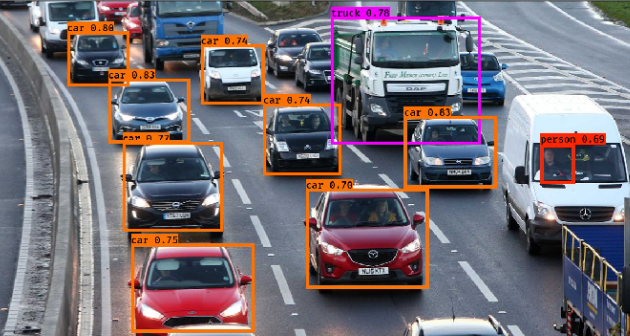

<div style="
    background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb);
    padding:18px;
    border-radius:14px;
    text-align:center;
    box-shadow:0 5px 15px rgba(0,0,0,0.25);
">

  <h2 style="
      margin:0;
      font-size:26px;
      color:white;
      font-weight:800;
      letter-spacing:0.5px;
  ">
    Import Libraries and Explore Kaggle Dataset Files
  </h2>

  <p style="
      margin-top:8px;
      font-size:15px;
      color:#dbeafe;
  ">
   
  </p>

</div>

In [1]:

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/ferozahmedds/vehicle-object-tracking-dataset/Vehicle Dataset Sample 1.mp4


<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Environment Setup and Dependency Installation
  </h2>
</div>

In [2]:
!pip uninstall -y torch torchvision torchaudio ultralytics
!pip install -q --no-cache-dir torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install -q --no-cache-dir ultralytics opencv-python-headless

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 296.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 210.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 305.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 273.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 301.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 367.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.

<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Import YOLO26 and Required Libraries
  </h2>
</div>

In [3]:


from ultralytics import YOLO
import cv2
import os
import numpy as np
from collections import defaultdict, deque
from IPython.display import Video, display

print("Import done")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Import done


<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Set Video Path and Verify Dataset Availability
  </h2>
</div>

In [4]:
VIDEO_PATH = "/kaggle/input/datasets/ferozahmedds/vehicle-object-tracking-dataset/Vehicle Dataset Sample 1.mp4"

if not os.path.exists(VIDEO_PATH):
    print("Video path not found. Checking /kaggle/input folders...")
    for root, dirs, files in os.walk("/kaggle/input"):
        for file in files:
            if file.endswith((".mp4", ".avi", ".mov", ".mkv")):
                print(os.path.join(root, file))
else:
    print("Video found:", VIDEO_PATH)

Video found: /kaggle/input/datasets/ferozahmedds/vehicle-object-tracking-dataset/Vehicle Dataset Sample 1.mp4


<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Load the YOLO26 Pretrained Model
  </h2>
</div>

In [5]:
model = YOLO("yolo26n.pt")

<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Verify PyTorch Version and GPU Availability
  </h2>
</div>

In [6]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla P100-PCIE-16GB


<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Configure Video Input, Target Classes, and Class Colors
  </h2>
</div>

In [7]:
import os, cv2, numpy as np
from collections import defaultdict, deque
from IPython.display import Video, display, FileLink

VIDEO_PATH = "/kaggle/input/datasets/ferozahmedds/vehicle-object-tracking-dataset/Vehicle Dataset Sample 1.mp4"

if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {VIDEO_PATH}")

TARGET_CLASSES = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}

CLASS_COLORS = {
    "car": (0, 0, 255),          # red
    "motorcycle": (0, 255, 0),   # green
    "bus": (255, 0, 0),          # blue
    "truck": (0, 255, 255)       # yellow
}

print("Video ready:", VIDEO_PATH)

Video ready: /kaggle/input/datasets/ferozahmedds/vehicle-object-tracking-dataset/Vehicle Dataset Sample 1.mp4


<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Define Helper Functions for Text Overlay, Size Classification, and Analytics Dashboard
  </h2>
</div>

In [8]:
def draw_text(img, text, pos, color=(255,255,255), scale=0.6, thickness=2):
    cv2.putText(img, text, pos, cv2.FONT_HERSHEY_SIMPLEX,
                scale, color, thickness, cv2.LINE_AA)


def get_size_category(box_area, frame_area):
    ratio = box_area / frame_area
    if ratio < 0.015:
        return "small"
    elif ratio < 0.06:
        return "medium"
    else:
        return "large"


def make_dashboard(panel_w, frame_h, live_count, peak_count, class_counts, size_counts, history):
    dash = np.zeros((frame_h, panel_w, 3), dtype=np.uint8)
    dash[:] = (20, 8, 25)

    white = (240, 240, 240)
    yellow = (0, 255, 255)
    green = (0, 255, 0)

    # Header
    cv2.rectangle(dash, (0, 0), (panel_w, 45), (35, 15, 45), -1)
    draw_text(dash, "Analytics Dashboard", (70, 30), white, 0.75, 2)

    # Live chart box
    y0, y1 = 60, 250
    cv2.rectangle(dash, (15, y0), (panel_w - 15, y1), (35, 18, 40), -1)
    draw_text(dash, f"Live: {live_count}", (30, y0 + 30), green, 0.6, 2)
    draw_text(dash, f"Peak: {peak_count}", (panel_w - 150, y0 + 30), green, 0.6, 2)
    draw_text(dash, "Total Objects per Frame", (30, y0 + 65), white, 0.55, 2)

    if len(history) > 1:
        chart_x0, chart_y0 = 30, y0 + 85
        chart_x1, chart_y1 = panel_w - 30, y1 - 20
        max_val = max(max(history), 1)

        points = []
        hist = list(history)
        for i, val in enumerate(hist):
            x = int(chart_x0 + i * (chart_x1 - chart_x0) / max(len(hist) - 1, 1))
            y = int(chart_y1 - val * (chart_y1 - chart_y0) / max_val)
            points.append((x, y))

        for i in range(1, len(points)):
            cv2.line(dash, points[i - 1], points[i], yellow, 2)

    # Vehicle class bar chart
    y0, y1 = 270, 470
    cv2.rectangle(dash, (15, y0), (panel_w - 15, y1), (30, 12, 35), -1)
    draw_text(dash, "Vehicle Count by Class", (30, y0 + 32), white, 0.58, 2)

    classes = ["car", "motorcycle", "bus", "truck"]
    values = [class_counts.get(c, 0) for c in classes]
    max_val = max(max(values), 1)

    bar_w = 52
    gap = 35
    start_x = 35
    base_y = y1 - 35

    for i, cls in enumerate(classes):
        val = values[i]
        x = start_x + i * (bar_w + gap)
        bar_h = int((val / max_val) * 90)
        y_bar = base_y - bar_h

        cv2.rectangle(dash, (x, y_bar), (x + bar_w, base_y), CLASS_COLORS[cls], -1)
        draw_text(dash, str(val), (x + 16, y_bar - 8), white, 0.45, 1)
        draw_text(dash, cls[:6], (x - 2, y1 - 10), CLASS_COLORS[cls], 0.42, 1)

    # Size category bar chart
    y0, y1 = 490, frame_h - 20
    cv2.rectangle(dash, (15, y0), (panel_w - 15, y1), (30, 12, 35), -1)
    draw_text(dash, "Object Counts by Size Category", (30, y0 + 32), white, 0.55, 2)

    sizes = ["small", "medium", "large"]
    size_colors = {
        "small": (255, 0, 255),
        "medium": (0, 165, 255),
        "large": (0, 255, 255)
    }

    values = [size_counts.get(s, 0) for s in sizes]
    max_val = max(max(values), 1)

    bar_w = 78
    gap = 45
    start_x = 50
    base_y = y1 - 40

    for i, size in enumerate(sizes):
        val = values[i]
        x = start_x + i * (bar_w + gap)
        bar_h = int((val / max_val) * 125)
        y_bar = base_y - bar_h

        cv2.rectangle(dash, (x, y_bar), (x + bar_w, base_y), size_colors[size], -1)
        draw_text(dash, str(val), (x + 28, y_bar - 8), white, 0.45, 1)
        draw_text(dash, size, (x + 5, y1 - 12), size_colors[size], 0.45, 1)

    return dash

In [9]:
cap = cv2.VideoCapture(VIDEO_PATH)

fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

panel_w = 420
output_w = frame_w + panel_w
output_h = frame_h

OUTPUT_PATH = "/kaggle/working/yolo26_same_dashboard_output.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (output_w, output_h))

history = deque(maxlen=80)
peak_count = 0
track_memory = set()
frame_area = frame_w * frame_h

frame_no = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_no += 1

    results = model.track(
        source=frame,
        persist=True,
        tracker="bytetrack.yaml",
        conf=0.25,
        iou=0.50,
        verbose=False
    )

    result = results[0]

    live_count = 0
    class_counts = defaultdict(int)
    size_counts = defaultdict(int)

    if result.boxes is not None:
        for box in result.boxes:
            cls_id = int(box.cls[0])

            if cls_id not in TARGET_CLASSES:
                continue

            class_name = TARGET_CLASSES[cls_id]
            color = CLASS_COLORS[class_name]

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])

            track_id = None
            if box.id is not None:
                track_id = int(box.id[0])
                track_memory.add((class_name, track_id))

            live_count += 1
            class_counts[class_name] += 1

            box_area = max(0, x2 - x1) * max(0, y2 - y1)
            size_cat = get_size_category(box_area, frame_area)
            size_counts[size_cat] += 1

            # Bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)

            label = f"{class_name} {conf:.2f}"
            if track_id is not None:
                label = f"{class_name} ID:{track_id}"

            # Label background
            label_w = max(130, len(label) * 10)
            cv2.rectangle(frame, (x1, max(0, y1 - 28)), (x1 + label_w, y1), color, -1)
            draw_text(frame, label, (x1 + 5, y1 - 8), (255,255,255), 0.48, 1)

    peak_count = max(peak_count, live_count)
    history.append(live_count)

    # Top-left overlay same style
    overlay = frame.copy()
    cv2.rectangle(overlay, (10, 10), (340, 205), (0, 0, 0), -1)
    frame = cv2.addWeighted(overlay, 0.52, frame, 0.48, 0)

    draw_text(frame, "Detection Summary", (20, 38), (255, 255, 255), 0.72, 2)
    draw_text(frame, f"Live Objects: {live_count}", (20, 72), (0, 255, 255), 0.68, 2)
    draw_text(frame, f"Unique Tracks: {len(track_memory)}", (20, 103), (255, 255, 255), 0.62, 2)

    draw_text(frame, f"Car: {class_counts.get('car', 0)}", (20, 132), CLASS_COLORS["car"], 0.58, 2)
    draw_text(frame, f"Motorcycle: {class_counts.get('motorcycle', 0)}", (20, 157), CLASS_COLORS["motorcycle"], 0.58, 2)
    draw_text(frame, f"Bus: {class_counts.get('bus', 0)}", (20, 182), CLASS_COLORS["bus"], 0.58, 2)
    draw_text(frame, f"Truck: {class_counts.get('truck', 0)}", (170, 182), CLASS_COLORS["truck"], 0.58, 2)

    dashboard = make_dashboard(
        panel_w=panel_w,
        frame_h=frame_h,
        live_count=live_count,
        peak_count=peak_count,
        class_counts=class_counts,
        size_counts=size_counts,
        history=history
    )

    combined = np.hstack((frame, dashboard))
    writer.write(combined)

    if frame_no % 50 == 0:
        print(f"Processed {frame_no} frames...")

cap.release()
writer.release()

print("Done!")
print("Saved:", OUTPUT_PATH)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 241ms
Prepared 1 package in 57ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Processed 50 frames...
Processed 100 frames...
Processed 150 frames...
Processed 200 frames...
Processed 250 frames...
Processed 300 frames...
Processed 350 frames...
Processed 400 frames...
Processed 450 frames...
Processed 500 frames...
Processed 550 frames...
Processed 600 frames...
Processed 650 frames...
Processed 700 frames...
Processed 750 frames...
Processed 800 frames...
Processed 850 frames...
Processed 900 frames...
Processed 950 frames...
Processed 1000 frames...
Processed 1050 frames...
Processed 1100 frames...
Processed 1150 frames...
Processed 1200 frames...
Processed 1250 frames...
Processed 1300 frames...
Processed 135

<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Display the Final YOLO26 Vehicle Analytics Output Video
  </h2>
</div>

In [ ]:
display(Video(OUTPUT_PATH, embed=True, width=1200))

<div style="background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb); padding:18px; border-radius:14px; text-align:center; box-shadow:0 5px 15px rgba(0,0,0,0.25);">
  <h2 style="margin:0; font-size:26px; color:white; font-weight:800; letter-spacing:0.5px;">
    Generate Download Link for the Final Output Video
  </h2>
</div>

In [11]:
FileLink(OUTPUT_PATH)

/kaggle/working/yolo26_same_dashboard_output.mp4

<div style="
    background: linear-gradient(135deg,#0f172a,#1e3a8a,#2563eb);
    padding:25px;
    border-radius:16px;
    text-align:center;
    box-shadow:0 6px 18px rgba(0,0,0,0.3);
">

  <h2 style="
      margin:0;
      font-size:30px;
      color:white;
      font-weight:800;
      letter-spacing:0.5px;
  ">
    Project Summary and Thank You
  </h2>

  <p style="
      margin-top:14px;
      font-size:16px;
      color:#dbeafe;
      line-height:1.7;
  ">
    This project demonstrates a YOLO26-based vehicle detection and tracking system for traffic video analysis.
    The system detects cars, motorcycles, buses, and trucks, tracks objects using ByteTrack, counts vehicles in real time,
    and generates an analytics dashboard with class-wise and size-wise visualization.
  </p>

  <p style="
      margin-top:16px;
      font-size:17px;
      color:white;
      font-weight:700;
  ">
    Thank you for exploring this project.
  </p>

</div>